# 08. State Dependence and Nonlinearity

This notebook examines heterogeneity in reform effects by:
1. Initial income level (state dependence)
2. Initial economic freedom level
3. Magnitude of reform (dose-response)

**Key question:** Do effects vary by country characteristics at time of reform?

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS
import matplotlib.pyplot as plt
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Project paths
PROJECT_ROOT = Path(__file__).parent.parent if '__file__' in dir() else Path.cwd().parent
DATA_CLEAN = PROJECT_ROOT / 'data/03_clean'
OUTPUT_FIGURES = PROJECT_ROOT / 'output/figures'
OUTPUT_TABLES = PROJECT_ROOT / 'output/tables'
OUTPUT_LOGS = PROJECT_ROOT / 'output/logs'

for d in [OUTPUT_FIGURES, OUTPUT_TABLES, OUTPUT_LOGS]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")

K = 4
L = 6

Project root: /Users/gabrielsaco/Documents/GitHub/economic-freedom


## 1. Load Data

In [2]:
stacked_pos = pd.read_parquet(DATA_CLEAN / 'stacked_events_pos.parquet')
stacked_neg = pd.read_parquet(DATA_CLEAN / 'stacked_events_neg.parquet')

print(f"Positive reforms: {len(stacked_pos)} obs")
print(f"Negative reforms: {len(stacked_neg)} obs")

# Check for state dependence variables
state_vars = ['ln_gdp_pc_lag1', 'efw_aggregate_lag1', 'gdp_quartile', 'efw_quartile']
for var in state_vars:
    if var in stacked_pos.columns:
        print(f"  ✓ {var} available")
    else:
        print(f"  ✗ {var} not available")

Positive reforms: 45184 obs
Negative reforms: 18408 obs
  ✓ ln_gdp_pc_lag1 available
  ✓ efw_aggregate_lag1 available
  ✓ gdp_quartile available
  ✓ efw_quartile available


## 2. Create State Indicators

We split the sample by initial conditions:
- High vs Low initial income (above/below median)
- High vs Low initial EFW (above/below median)

In [3]:
def add_state_indicators(df, use_lag=True):
    """Add binary indicators for state dependence analysis."""
    df = df.copy()
    
    # Get initial conditions from t-1 (preserved from panel merge)
    if use_lag and 'ln_gdp_pc_lag1' in df.columns:
        gdp_var = 'ln_gdp_pc_lag1'
    else:
        gdp_var = 'ln_gdp_pc'
    
    if use_lag and 'efw_aggregate_lag1' in df.columns:
        efw_var = 'efw_aggregate_lag1'
    else:
        efw_var = 'efw_aggregate'
    
    # Compute median within treated units at t=0
    treated_at_0 = df[(df['treated'] == 1) & (df['event_time'] == 0)]
    
    if gdp_var in treated_at_0.columns:
        gdp_median = treated_at_0[gdp_var].median()
        df['high_income'] = (df[gdp_var] >= gdp_median).astype(int)
        df['low_income'] = 1 - df['high_income']
        print(f"GDP median (at t=0): {gdp_median:.3f}")
    
    if efw_var in treated_at_0.columns:
        efw_median = treated_at_0[efw_var].median()
        df['high_efw'] = (df[efw_var] >= efw_median).astype(int)
        df['low_efw'] = 1 - df['high_efw']
        print(f"EFW median (at t=0): {efw_median:.3f}")
    
    return df

stacked_pos = add_state_indicators(stacked_pos)
stacked_neg = add_state_indicators(stacked_neg)

GDP median (at t=0): 7.928
EFW median (at t=0): 4.589
GDP median (at t=0): 7.886
EFW median (at t=0): 5.540


## 3. Estimate State-Dependent Effects

In [4]:
def estimate_by_state(df, state_col, outcome_col='y_cumulative', K=2, L=4):
    """
    Estimate event study separately for high and low states.
    """
    results = {}
    
    for state_val, state_name in [(1, 'High'), (0, 'Low')]:
        df_state = df[df[state_col] == state_val].copy()
        
        if len(df_state) < 100:
            print(f"  {state_name}: Too few observations ({len(df_state)})")
            results[state_name] = None
            continue
        
        # Estimate
        df_state = df_state.dropna(subset=[outcome_col])
        
        # Create treatment interactions
        for k in range(-K, L+1):
            if k == -1:
                continue
            col_name = f'treat_et_{k}' if k < 0 else f'treat_et_p{k}'
            if col_name not in df_state.columns:
                df_state[col_name] = ((df_state['treated'] == 1) & 
                                       (df_state['event_time'] == k)).astype(int)
        
        # Demean
        df_state['cohort_country'] = df_state['cohort_id'] + '_' + df_state['iso3c']
        cc_means = df_state.groupby('cohort_country')[outcome_col].transform('mean')
        df_state['y_dm'] = df_state[outcome_col] - cc_means
        
        treat_cols = []
        for k in range(-K, L+1):
            if k == -1:
                continue
            col_name = f'treat_et_{k}' if k < 0 else f'treat_et_p{k}'
            treat_cols.append(col_name)
        
        for col in treat_cols:
            cc_mean = df_state.groupby('cohort_country')[col].transform('mean')
            df_state[col + '_dm'] = df_state[col] - cc_mean
        
        X = df_state[[c + '_dm' for c in treat_cols]].values
        X_const = np.column_stack([np.ones(len(df_state)), X])
        y = df_state['y_dm'].values
        
        # Estimate with clustered SEs
        model = OLS(y, X_const)
        fit = model.fit(cov_type='cluster', cov_kwds={'groups': df_state['iso3c']})
        
        # Extract coefficients
        estimates = {}
        for i, col in enumerate(treat_cols):
            k = int(col.replace('treat_et_', '').replace('p', '').replace('_dm', ''))
            if 'et_-' in col:
                k = -k
            estimates[k] = {
                'coef': fit.params[i+1],
                'se': fit.bse[i+1],
                'pval': fit.pvalues[i+1],
            }
        estimates[-1] = {'coef': 0, 'se': 0, 'pval': np.nan}  # Reference
        
        results[state_name] = {
            'estimates': estimates,
            'n_obs': len(y),
            'n_clusters': df_state['iso3c'].nunique(),
        }
        
        print(f"  {state_name}: {len(y)} obs, {df_state['iso3c'].nunique()} clusters")
    
    return results

## 4. Estimate by Income Level

In [5]:
print("\nEstimating by INCOME LEVEL (Positive Reforms)...")
if 'high_income' in stacked_pos.columns:
    income_results_pos = estimate_by_state(stacked_pos, 'high_income', K=K, L=L)
else:
    income_results_pos = None
    print("  Income variable not available")

print("\nEstimating by INCOME LEVEL (Negative Reforms)...")
if 'high_income' in stacked_neg.columns:
    income_results_neg = estimate_by_state(stacked_neg, 'high_income', K=K, L=L)
else:
    income_results_neg = None


Estimating by INCOME LEVEL (Positive Reforms)...
  High: 21297 obs, 111 clusters
  Low: 19296 obs, 163 clusters

Estimating by INCOME LEVEL (Negative Reforms)...
  High: 7973 obs, 113 clusters
  Low: 7337 obs, 164 clusters


## 5. Estimate by Initial EFW Level

In [6]:
print("\nEstimating by INITIAL EFW (Positive Reforms)...")
if 'high_efw' in stacked_pos.columns:
    efw_results_pos = estimate_by_state(stacked_pos, 'high_efw', K=K, L=L)
else:
    efw_results_pos = None
    print("  EFW variable not available")

print("\nEstimating by INITIAL EFW (Negative Reforms)...")
if 'high_efw' in stacked_neg.columns:
    efw_results_neg = estimate_by_state(stacked_neg, 'high_efw', K=K, L=L)
else:
    efw_results_neg = None


Estimating by INITIAL EFW (Positive Reforms)...
  High: 28663 obs, 160 clusters
  Low: 11930 obs, 161 clusters

Estimating by INITIAL EFW (Negative Reforms)...
  High: 7763 obs, 142 clusters
  Low: 7547 obs, 163 clusters


## 6. Plot State-Dependent IRFs

✓ Saved figure to /Users/gabrielsaco/Documents/GitHub/economic-freedom/output/figures/fig_irf_state_income_pos.pdf


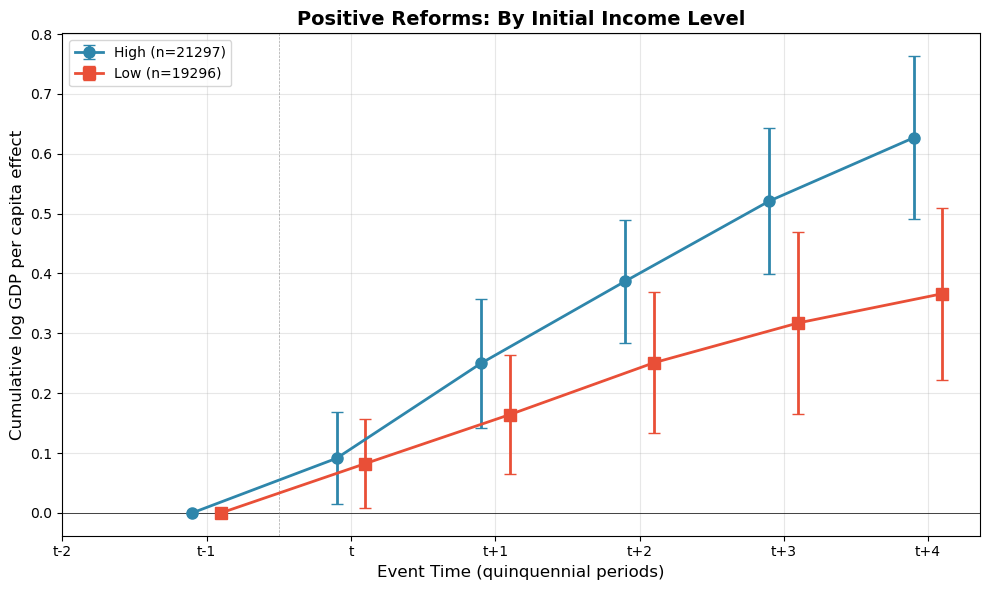

✓ Saved figure to /Users/gabrielsaco/Documents/GitHub/economic-freedom/output/figures/fig_irf_state_income_neg.pdf


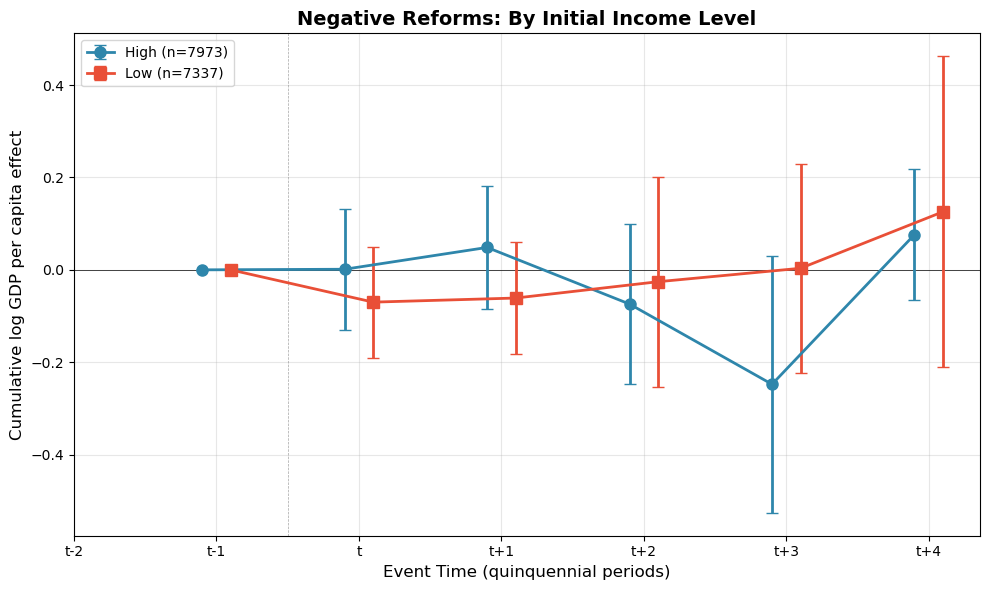

✓ Saved figure to /Users/gabrielsaco/Documents/GitHub/economic-freedom/output/figures/fig_irf_state_efw_pos.pdf


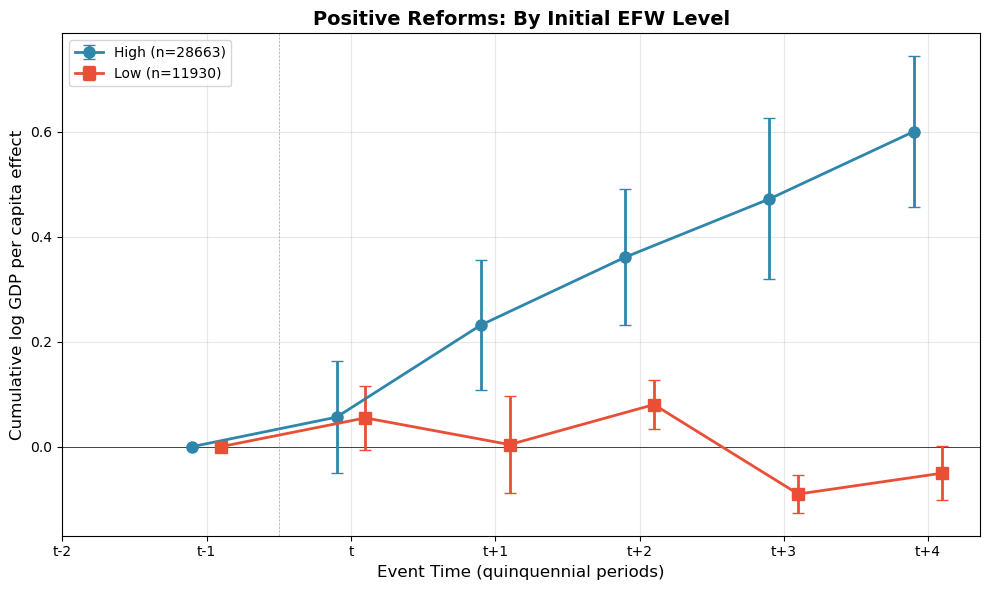

✓ Saved figure to /Users/gabrielsaco/Documents/GitHub/economic-freedom/output/figures/fig_irf_state_efw_neg.pdf


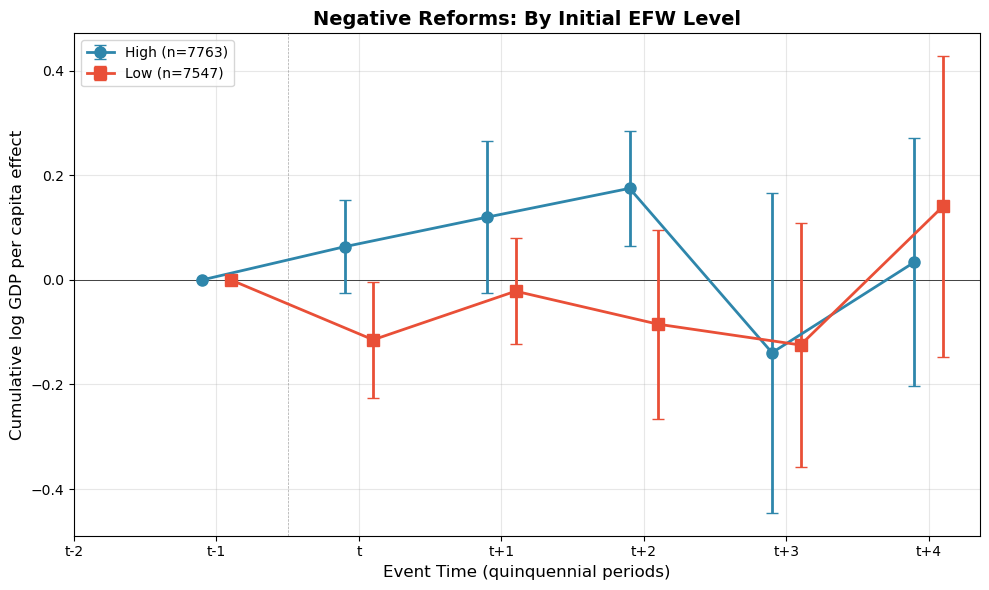

In [7]:
def plot_state_irf(results_high, results_low, K=2, L=4, title='', save_path=None):
    """Plot IRFs by state (high vs low)."""
    if results_high is None or results_low is None:
        print(f"Cannot plot: missing results for {title}")
        return
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    event_times = list(range(-K, L+1))
    
    # High state
    coefs_high = [results_high['estimates'].get(k, {}).get('coef', np.nan) for k in event_times]
    ses_high = [results_high['estimates'].get(k, {}).get('se', np.nan) for k in event_times]
    
    # Low state
    coefs_low = [results_low['estimates'].get(k, {}).get('coef', np.nan) for k in event_times]
    ses_low = [results_low['estimates'].get(k, {}).get('se', np.nan) for k in event_times]
    
    offset = 0.1
    
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax.axvline(x=-0.5, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
    
    # High state
    ax.errorbar([t - offset for t in event_times], coefs_high,
                yerr=[1.96*s if not np.isnan(s) else 0 for s in ses_high],
                fmt='o-', color='#2E86AB', capsize=4, markersize=8, linewidth=2,
                label=f'High (n={results_high["n_obs"]})')
    
    # Low state
    ax.errorbar([t + offset for t in event_times], coefs_low,
                yerr=[1.96*s if not np.isnan(s) else 0 for s in ses_low],
                fmt='s-', color='#E94F37', capsize=4, markersize=8, linewidth=2,
                label=f'Low (n={results_low["n_obs"]})')
    
    ax.set_xlabel('Event Time (quinquennial periods)', fontsize=12)
    ax.set_ylabel('Cumulative log GDP per capita effect', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xticks(event_times)
    ax.set_xticklabels([f't{k:+d}' if k != 0 else 't' for k in event_times])
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ Saved figure to {save_path}")
    
    plt.show()
    return fig

# Plot by income
if income_results_pos and income_results_pos.get('High') and income_results_pos.get('Low'):
    plot_state_irf(
        income_results_pos['High'], income_results_pos['Low'],
        K=K, L=L,
        title='Positive Reforms: By Initial Income Level',
        save_path=OUTPUT_FIGURES / 'fig_irf_state_income_pos.pdf'
    )

if income_results_neg and income_results_neg.get('High') and income_results_neg.get('Low'):
    plot_state_irf(
        income_results_neg['High'], income_results_neg['Low'],
        K=K, L=L,
        title='Negative Reforms: By Initial Income Level',
        save_path=OUTPUT_FIGURES / 'fig_irf_state_income_neg.pdf'
    )

# Plot by EFW
if efw_results_pos and efw_results_pos.get('High') and efw_results_pos.get('Low'):
    plot_state_irf(
        efw_results_pos['High'], efw_results_pos['Low'],
        K=K, L=L,
        title='Positive Reforms: By Initial EFW Level',
        save_path=OUTPUT_FIGURES / 'fig_irf_state_efw_pos.pdf'
    )

if efw_results_neg and efw_results_neg.get('High') and efw_results_neg.get('Low'):
    plot_state_irf(
        efw_results_neg['High'], efw_results_neg['Low'],
        K=K, L=L,
        title='Negative Reforms: By Initial EFW Level',
        save_path=OUTPUT_FIGURES / 'fig_irf_state_efw_neg.pdf'
    )

## 7. Magnitude Nonlinearity (Dose-Response)

Examine whether larger reforms have proportionally larger effects.

In [8]:
# Load panel with shock magnitudes
panel = pd.read_parquet(DATA_CLEAN / 'panel_with_shocks.parquet')

# Get reform magnitudes for treated observations
def add_reform_magnitude(stacked_df, panel_df):
    """Add reform magnitude to stacked data."""
    # Get magnitude at t=0 for treated units
    treated_events = stacked_df[(stacked_df['treated'] == 1) & (stacked_df['event_time'] == 0)]
    treated_events = treated_events[['cohort_id', 'iso3c', 'year']].drop_duplicates()
    
    # Merge with panel to get d_efw_aggregate
    if 'd_efw_aggregate' in panel_df.columns:
        magnitudes = treated_events.merge(
            panel_df[['iso3c', 'year', 'd_efw_aggregate']],
            on=['iso3c', 'year'],
            how='left'
        )
        
        # Add to stacked data
        stacked_df = stacked_df.merge(
            magnitudes[['cohort_id', 'd_efw_aggregate']].rename(columns={'d_efw_aggregate': 'reform_magnitude'}),
            on='cohort_id',
            how='left'
        )
    
    return stacked_df

stacked_pos = add_reform_magnitude(stacked_pos, panel)
stacked_neg = add_reform_magnitude(stacked_neg, panel)

print("Reform magnitude summary (Positive):")
if 'reform_magnitude' in stacked_pos.columns:
    mag_pos = stacked_pos[stacked_pos['treated'] == 1]['reform_magnitude'].dropna()
    print(f"  Mean: {mag_pos.mean():.3f}")
    print(f"  Std: {mag_pos.std():.3f}")
    print(f"  Min: {mag_pos.min():.3f}, Max: {mag_pos.max():.3f}")

print("\nReform magnitude summary (Negative):")
if 'reform_magnitude' in stacked_neg.columns:
    mag_neg = stacked_neg[stacked_neg['treated'] == 1]['reform_magnitude'].dropna()
    print(f"  Mean: {mag_neg.mean():.3f}")
    print(f"  Std: {mag_neg.std():.3f}")
    print(f"  Min: {mag_neg.min():.3f}, Max: {mag_neg.max():.3f}")

Reform magnitude summary (Positive):
  Mean: 1.350
  Std: 0.340
  Min: 1.022, Max: 2.845

Reform magnitude summary (Negative):
  Mean: -1.297
  Std: 0.238
  Min: -1.938, Max: -1.017


## 8. Estimate by Reform Magnitude


Estimating by MAGNITUDE (Positive Reforms)...
  Median |magnitude|: 1.246
  Large: 21130 obs
  Small: 19463 obs

Estimating by MAGNITUDE (Negative Reforms)...
  Median |magnitude|: 1.199
  Large: 8352 obs
  Small: 6958 obs
✓ Saved figure to /Users/gabrielsaco/Documents/GitHub/economic-freedom/output/figures/fig_irf_magnitude_pos.pdf


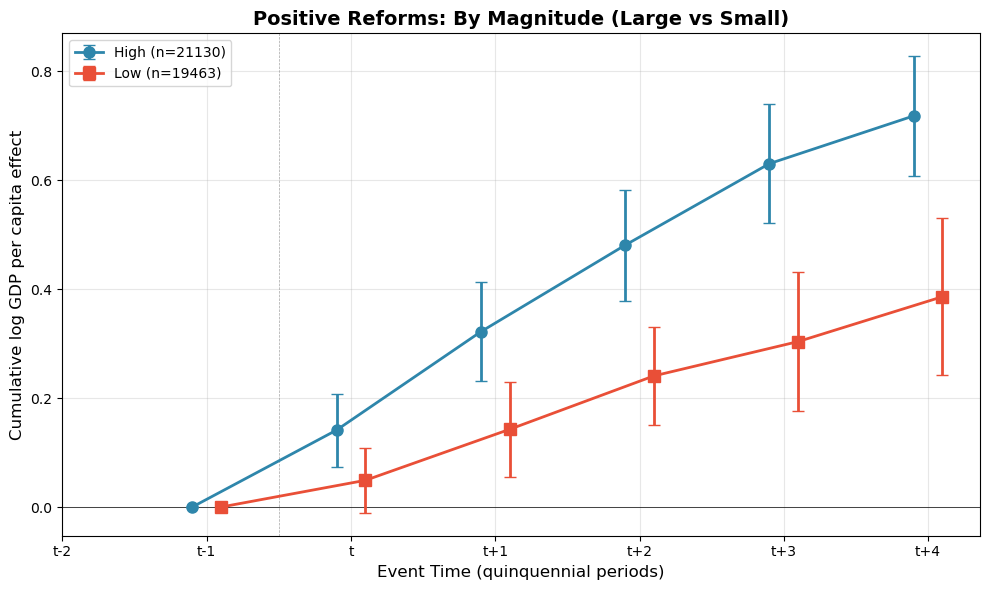

✓ Saved figure to /Users/gabrielsaco/Documents/GitHub/economic-freedom/output/figures/fig_irf_magnitude_neg.pdf


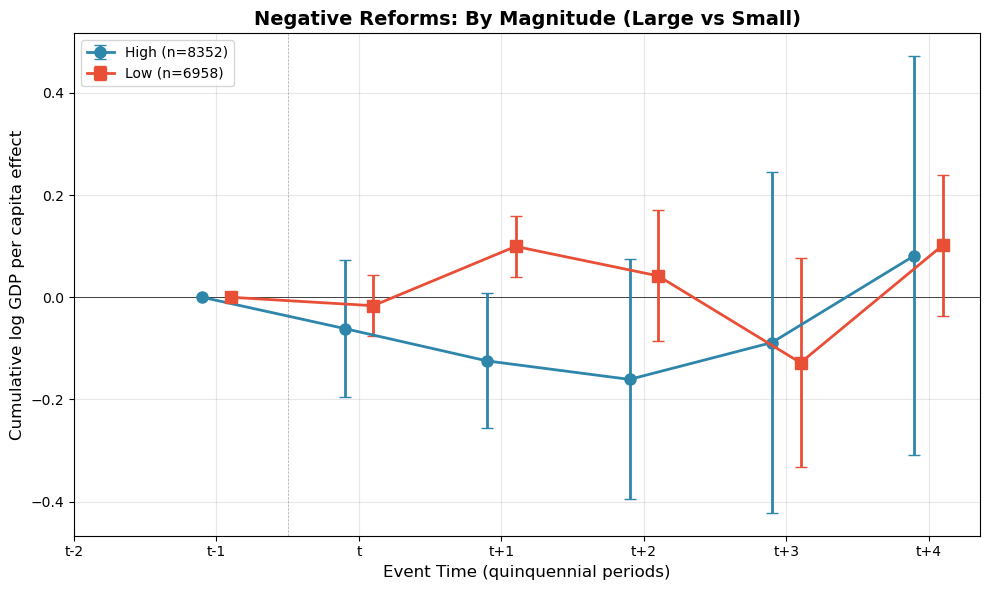

In [9]:
def estimate_by_magnitude(df, magnitude_col='reform_magnitude', outcome_col='y_cumulative', K=2, L=4):
    """
    Estimate effects separately for large vs small reforms.
    """
    if magnitude_col not in df.columns:
        print(f"  Magnitude column {magnitude_col} not found")
        return None
    
    # Get median magnitude among treated
    treated = df[(df['treated'] == 1) & (df['event_time'] == 0)]
    med_mag = treated[magnitude_col].abs().median()
    print(f"  Median |magnitude|: {med_mag:.3f}")
    
    # Split by magnitude
    df = df.copy()
    df['large_reform'] = (df[magnitude_col].abs() >= med_mag).astype(int)
    
    results = {}
    for is_large, label in [(1, 'Large'), (0, 'Small')]:
        df_sub = df[df['large_reform'] == is_large].copy()
        df_sub = df_sub.dropna(subset=[outcome_col])
        
        if len(df_sub) < 100:
            print(f"  {label}: Too few observations")
            results[label] = None
            continue
        
        # Create treatment interactions
        for k in range(-K, L+1):
            if k == -1:
                continue
            col_name = f'treat_et_{k}' if k < 0 else f'treat_et_p{k}'
            if col_name not in df_sub.columns:
                df_sub[col_name] = ((df_sub['treated'] == 1) & 
                                    (df_sub['event_time'] == k)).astype(int)
        
        # Demean
        df_sub['cohort_country'] = df_sub['cohort_id'] + '_' + df_sub['iso3c']
        cc_means = df_sub.groupby('cohort_country')[outcome_col].transform('mean')
        df_sub['y_dm'] = df_sub[outcome_col] - cc_means
        
        treat_cols = []
        for k in range(-K, L+1):
            if k == -1:
                continue
            col_name = f'treat_et_{k}' if k < 0 else f'treat_et_p{k}'
            treat_cols.append(col_name)
        
        for col in treat_cols:
            cc_mean = df_sub.groupby('cohort_country')[col].transform('mean')
            df_sub[col + '_dm'] = df_sub[col] - cc_mean
        
        X = df_sub[[c + '_dm' for c in treat_cols]].values
        X_const = np.column_stack([np.ones(len(df_sub)), X])
        y = df_sub['y_dm'].values
        
        model = OLS(y, X_const)
        fit = model.fit(cov_type='cluster', cov_kwds={'groups': df_sub['iso3c']})
        
        estimates = {}
        for i, col in enumerate(treat_cols):
            k = int(col.replace('treat_et_', '').replace('p', '').replace('_dm', ''))
            if 'et_-' in col:
                k = -k
            estimates[k] = {
                'coef': fit.params[i+1],
                'se': fit.bse[i+1],
            }
        estimates[-1] = {'coef': 0, 'se': 0}
        
        results[label] = {
            'estimates': estimates,
            'n_obs': len(y),
            'n_clusters': df_sub['iso3c'].nunique(),
        }
        print(f"  {label}: {len(y)} obs")
    
    return results

print("\nEstimating by MAGNITUDE (Positive Reforms)...")
mag_results_pos = estimate_by_magnitude(stacked_pos, K=K, L=L)

print("\nEstimating by MAGNITUDE (Negative Reforms)...")
mag_results_neg = estimate_by_magnitude(stacked_neg, K=K, L=L)

# Plot magnitude heterogeneity
if mag_results_pos and mag_results_pos.get('Large') and mag_results_pos.get('Small'):
    plot_state_irf(
        mag_results_pos['Large'], mag_results_pos['Small'],
        K=K, L=L,
        title='Positive Reforms: By Magnitude (Large vs Small)',
        save_path=OUTPUT_FIGURES / 'fig_irf_magnitude_pos.pdf'
    )

if mag_results_neg and mag_results_neg.get('Large') and mag_results_neg.get('Small'):
    plot_state_irf(
        mag_results_neg['Large'], mag_results_neg['Small'],
        K=K, L=L,
        title='Negative Reforms: By Magnitude (Large vs Small)',
        save_path=OUTPUT_FIGURES / 'fig_irf_magnitude_neg.pdf'
    )

## 9. Summary Table

In [10]:
def summarize_state_dependence(results_dict, state_names):
    """Create summary table of state-dependent effects."""
    rows = []
    
    for state_name in state_names:
        res = results_dict.get(state_name)
        if res is None:
            continue
        
        # Compute cumulative effect (sum of post-treatment)
        post_coefs = [res['estimates'].get(k, {}).get('coef', 0) for k in range(0, 5)]
        cumulative = sum([c for c in post_coefs if not np.isnan(c)])
        
        # Impact effect (h=0)
        impact = res['estimates'].get(0, {}).get('coef', np.nan)
        
        rows.append({
            'State': state_name,
            'N_obs': res.get('n_obs', np.nan),
            'N_clusters': res.get('n_clusters', np.nan),
            'Impact (h=0)': impact,
            'Cumulative': cumulative,
        })
    
    return pd.DataFrame(rows)

# Create summary tables
print("\n" + "="*60)
print("STATE DEPENDENCE SUMMARY")
print("="*60)

if income_results_pos:
    print("\nBy Income Level (Positive Reforms):")
    summary_income_pos = summarize_state_dependence(income_results_pos, ['High', 'Low'])
    print(summary_income_pos.to_string(index=False))

if efw_results_pos:
    print("\nBy Initial EFW (Positive Reforms):")
    summary_efw_pos = summarize_state_dependence(efw_results_pos, ['High', 'Low'])
    print(summary_efw_pos.to_string(index=False))

if mag_results_pos:
    print("\nBy Magnitude (Positive Reforms):")
    summary_mag_pos = summarize_state_dependence(mag_results_pos, ['Large', 'Small'])
    print(summary_mag_pos.to_string(index=False))


STATE DEPENDENCE SUMMARY

By Income Level (Positive Reforms):
State  N_obs  N_clusters  Impact (h=0)  Cumulative
 High  21297         111      0.091174    1.875423
  Low  19296         163      0.082398    1.180876

By Initial EFW (Positive Reforms):
State  N_obs  N_clusters  Impact (h=0)  Cumulative
 High  28663         160      0.056094    1.719483
  Low  11930         161      0.054713   -0.002083

By Magnitude (Positive Reforms):
State  N_obs  N_clusters  Impact (h=0)  Cumulative
Large  21130         160      0.141119    2.291133
Small  19463         161      0.048992    1.121866


## 10. Save Results

In [11]:
# Compile results
state_results = {
    'timestamp': datetime.now().isoformat(),
    'income_dependence': {
        'positive': income_results_pos if income_results_pos else {},
        'negative': income_results_neg if income_results_neg else {},
    },
    'efw_dependence': {
        'positive': efw_results_pos if efw_results_pos else {},
        'negative': efw_results_neg if efw_results_neg else {},
    },
    'magnitude_dependence': {
        'positive': mag_results_pos if mag_results_pos else {},
        'negative': mag_results_neg if mag_results_neg else {},
    }
}

# Convert numpy types for JSON
def convert_numpy(obj):
    if isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, dict):
        return {k: convert_numpy(v) for k, v in obj.items()}
    return obj

state_results = convert_numpy(state_results)

results_path = OUTPUT_LOGS / 'state_dependence_results.json'
with open(results_path, 'w') as f:
    json.dump(state_results, f, indent=2, default=str)

print(f"\n✓ Saved state dependence results to {results_path}")

print("\n" + "="*60)
print("08_STATE_DEPENDENCE_NONLINEARITY COMPLETE")
print("="*60)


✓ Saved state dependence results to /Users/gabrielsaco/Documents/GitHub/economic-freedom/output/logs/state_dependence_results.json

08_STATE_DEPENDENCE_NONLINEARITY COMPLETE
